# Sr2ZnReO6: ZF-muSR field distributions

Here we present the results discussed in the published article [here](https://journals.aps.org/prb/abstract/10.1103/2ngs-7x82).

M. M. Isah et al., Phys. Rev. B 113, 104431 (2026) [DOI: https://doi.org/10.1103/2ngs-7x82](https://journals.aps.org/prb/abstract/10.1103/2ngs-7x82).

In [1]:
import pickle
import dill as pickle
import numpy as np
from copy import deepcopy
from ase.io import read
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

## for plotting if needed
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants
from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

import muonscripts.io_tools as ios
import muonscripts.io_tools.read_qe  as qe
import muonscripts.io_tools.read_elk  as elk

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.muon_tools import contact_field
from muonscripts.muon_tools.muonic_dataframe import get_dataframe
from muonscripts.muon_tools.distortions.distortions import get_structs
from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muon_tools.nearby import _group_fmt
from muonscripts.muon_tools.nearby import nearby_atom
from muonscripts.muon_tools.nearby import print_muon_table
from muonscripts.muon_tools.nearby import get_group_nearby_atom

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muesr_tools.local_fields import pfields, rfields
from muonscripts.muesr_tools.local_fields import multisite_pfields
from muonscripts.muesr_tools.utils import _extract_muon, get_atom_kinds

from muonscripts.symmetry import wyckoff as wyckoff
from muonscripts.symmetry.sites import get_equivalent_sites

from muonscripts.plot_tools.muon import fancy_style_axes

In [3]:
# Define constants
S2PI = np.sqrt(2 * np.pi)
TINY = 1.0e-15
TESLA_TO_GAUSS = 1e4
GAMMA_MU_MHZ_GAUSS = constants.MUON_GYROMAGNETIC_RATIO/(2*np.pi)/TESLA_TO_GAUSS*1e-6
MHZ_TO_GAUSS = 1/GAMMA_MU_MHZ_GAUSS
GAUSS_TO_TESLA = 1/TESLA_TO_GAUSS
GAUSS_TO_MILLITESLA = GAUSS_TO_TESLA*1e3

In [4]:
def index_range_of(arrval, minval, maxval):
    """
    Return flat indices of elements within the specified range [minval, maxval].
    """
    arrval = np.asarray(arrval)
    return np.flatnonzero((arrval >= minval) & (arrval <= maxval))


def get_fourier_data(power=True, normalize=True):
    from scipy.signal import find_peaks

    file_name = 'oldruns_808_809_836_fourier_basetemp.dat'
    dat = np.loadtxt(file_name, delimiter=None)
    
    xdata = dat[:, 0]  # MHz
    yreal = dat[:, 1]
    yimgr = dat[:, 2]
    yerr  = dat[:, 3]

    ydata = yreal  # FFT real
    if power:
        ydata = yreal**2 + yimgr**2
    if normalize:
        peaks, _ = find_peaks(ydata)
        max_peak = np.max(ydata[peaks])
        ydata/=max_peak
    
    return xdata*MHZ_TO_GAUSS, ydata


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [5]:
def get_angle(v1, v2, units = "degrees"):
    """Calculate the angle between two vectors.

    Args:
        v1: Vector 1.
        v2: Vector 2.
        units: "degrees" or "radians". Defaults to "degrees".

    Returns:
        Angle between v1 and v2 in the specified units.
    """
    import math
    
    d = np.dot(v1, v2) / np.linalg.norm(v1) / np.linalg.norm(v2)
    d = min(d, 1)
    d = max(d, -1)
    angle = math.acos(d)
    if units == "degrees":
        return math.degrees(angle)
    if units == "radians":
        return angle
    raise ValueError(f"Invalid {units=}")

In [6]:
# 1. Check for lmfit availability
try:
    import lmfit
    HAS_LMFIT = True
except ImportError:
    HAS_LMFIT = False
    from scipy.optimize import curve_fit


def gaussian(x, amplitude=1.0, center=0.0, sigma=1.0):
    """1D Gaussian line shape."""
    return (amplitude / max(TINY, S2PI * sigma)) * np.exp(
        -((x - center) ** 2) / max(TINY, 2 * sigma**2)
    )


# 2. LMfit Implementation
def _fit_with_lmfit(xdat, ydat, diplst, parinit, parmin, parmax, vary_flags):
    # def sum_gaussians_model(params, x, diplst):
    #     amp = params['amplitude'].value
    #     mag = params['magmom'].value
    #     sig = params['sigma'].value
    #     off = params['offset'].value
        
    #     centers = diplst * mag
    #     rho = np.sum(
    #         [gaussian(x, amplitude=np.abs(amp), center=c, sigma=sig) for c in centers],
    #         axis=0
    #     )
    #     return rho + off

    # 1. Unpack parameters explicitly in the function signature!
    def sum_gaussians_model(x, diplst, amplitude, magmom, sigma, offset):
        centers = diplst * magmom
        rho = np.sum(
            [gaussian(x, amplitude=np.abs(amplitude), center=c, sigma=sigma) for c in centers],
            axis=0
        )
        return rho + offset

    # Build model & parameters
    model = lmfit.Model(sum_gaussians_model, independent_vars=['x', 'diplst'])
    params = lmfit.Parameters()
    
    parnames = ["amplitude", "magmom", "sigma", "offset"]
    for name, val, pmin, pmax, vary in zip(parnames, parinit, parmin, parmax, vary_flags):
        params.add(name, value=val, min=pmin, max=pmax, vary=vary)

    # Perform fit
    result = model.fit(ydat, params, x=xdat, diplst=diplst)

    # High-resolution fit curve
    xfit = np.linspace(np.min(xdat), np.max(xdat), 1000)
    yfit = result.eval(x=xfit, diplst=diplst)

    parvalues = [result.params[name].value for name in parnames]
    parerrors = [result.params[name].stderr or 0.0 for name in parnames]

    return {
        'xdat': xdat,
        'ydat': ydat,
        'xfit': xfit,
        'yfit': yfit,
        'dipolar': np.array(diplst),
        'parnames': parnames,
        'parvalues': np.array(parvalues),
        'parerrors': np.array(parerrors),
        'r2squared': result.rsquared,
        'backend': 'lmfit',
        'raw_result': result  # Grants access to lmfit.fit_report()
    }


# 3. SciPy Fallback Implementation
def _fit_with_scipy(xdat, ydat, diplst, parinit, parmin, parmax, vary_flags):
    parnames = ["amplitude", "magmom", "sigma", "offset"]
    p0_active = parinit[vary_flags]
    bounds_active = (parmin[vary_flags], parmax[vary_flags])

    def model_func(x, *active_params):
        params = parinit.copy()
        params[vary_flags] = active_params
        amp, mag, sig, off = params
        centers = diplst * mag
        rho = np.sum(
            [gaussian(x, amplitude=np.abs(amp), center=c, sigma=sig) for c in centers],
            axis=0
        )
        return rho + off

    popt_active, pcov_active = curve_fit(
        model_func, xdat, ydat, p0=p0_active, bounds=bounds_active
    )

    parvalues = parinit.copy()
    parvalues[vary_flags] = popt_active
    
    parerrors = np.zeros_like(parinit)
    parerrors[vary_flags] = np.sqrt(np.diag(pcov_active))

    # Goodness of fit calculations
    ytheory = model_func(xdat, *popt_active)
    ss_res = np.sum((ydat - ytheory) ** 2)
    ss_tot = np.sum((ydat - np.mean(ydat)) ** 2)
    r2squared = 1.0 - (ss_res / ss_tot)

    xfit = np.linspace(np.min(xdat), np.max(xdat), 1000)
    yfit = model_func(xfit, *popt_active)

    return {
        'xdat': xdat,
        'ydat': ydat,
        'xfit': xfit,
        'yfit': yfit,
        'dipolar': np.array(diplst),
        'parnames': parnames,
        'parvalues': parvalues,
        'parerrors': parerrors,
        'r2squared': r2squared,
        'backend': 'scipy',
        'raw_result': None
    }


# 4. Universal Wrapper Function
def fit_gaussian_model(
    xdat, 
    ydat, 
    diplst, 
    parinit, 
    parmin_bounds=-np.inf, 
    parmax_bounds=np.inf, 
    vary_flags=None
):
    """
    Fits field distribution data using lmfit if available, otherwise scipy.optimize.
    """
    n_params = len(parinit)
    parinit = np.array(parinit, dtype=float)
    diplst = np.array(diplst, dtype=float)

    if vary_flags is None:
        vary_flags = [True] * n_params
    else:
        vary_flags = np.array(vary_flags, dtype=bool)

    # Normalize bounds to arrays
    if np.isscalar(parmin_bounds):
        parmin_bounds = np.full(n_params, parmin_bounds)
    else:
        parmin_bounds = np.array(parmin_bounds, dtype=float)

    if np.isscalar(parmax_bounds):
        parmax_bounds = np.full(n_params, parmax_bounds)
    else:
        parmax_bounds = np.array(parmax_bounds, dtype=float)

    # Route execution depending on HAS_LMFIT flag
    if HAS_LMFIT:
        return _fit_with_lmfit(xdat, ydat, diplst, parinit, parmin_bounds, parmax_bounds, vary_flags)
    else:
        return _fit_with_scipy(xdat, ydat, diplst, parinit, parmin_bounds, parmax_bounds, vary_flags)

In [7]:
def dipolar_vlines(
    ax,
    dipolar,
    ymin=-0.025,
    ymax=0.025,
    lw=1.2,
    ls='solid',
    color='blue',
    alpha=1.0,
    label=None
):
    """
    Plots vertical lines corresponding to dipolar field positions using LineCollection.
    """
    dipolar = np.asarray(dipolar)
    if dipolar.size == 0:
        return ax

    segments = np.empty((len(dipolar), 2, 2))
    segments[:, 0, 0] = dipolar
    segments[:, 0, 1] = ymin
    segments[:, 1, 0] = dipolar
    segments[:, 1, 1] = ymax

    lc = LineCollection(
        segments,
        colors=color,
        linewidths=lw,
        linestyles=ls,
        alpha=alpha,
        label=label
    )
    ax.add_collection(lc)
    ax.autoscale_view()
    return ax
    

def format_param_uncertainty(val, err, mode='pm', sig_figs=2):
    """Formats value with uncertainty in 'pm' (val ± err) or 'compact' (val(err)) mode."""
    if err is None or err == 0 or np.isnan(err):
        return f"{val:.4f} (fixed)"
    
    order = int(np.floor(np.log10(abs(err))))
    prec = max(0, -order + (sig_figs - 1))
    
    if mode == 'compact':
        err_scaled = int(round(err * (10 ** prec)))
        return f"{val:.{prec}f}({err_scaled})"
    
    # Default 'pm' mode
    val_r, err_r = round(val, prec), round(err, prec)
    return f"{int(val_r)} ± {int(err_r)}" if prec == 0 else f"{val_r:.{prec}f} ± {err_r:.{prec}f}"


def build_printable_parameters(fitres, mode='pm', unit_sigma='mT', custom_labels=None, sig_figs=1):
    """Generates formatted parameter strings with selectable mode ('pm' or 'compact')."""
    labels = custom_labels or {'amplitude': 'Amp', 'magmom': r'$\mu$/Re', 'sigma': r'$\sigma$', 'offset': 'Bkg'}
    units = {'sigma': unit_sigma, 'magmom': r'$\mu_B$'}
    lines = []

    for name, val, err in zip(fitres['parnames'], fitres['parvalues'], fitres['parerrors']):
        label = labels.get(name, name)
        unit = units.get(name, "")
        
        if name == 'sigma' and unit_sigma == 'mT':
            val, err = val / 10.0, err / 10.0

        val_err_str = format_param_uncertainty(val, err, mode=mode, sig_figs=sig_figs)
        lines.append(f"{label}: {val_err_str} {unit}".strip())

    if 'r2squared' in fitres:
        lines.append(f"R$^2$ = {fitres['r2squared']:.4f}")

    return lines

In [8]:
import os
dpath='./'

In [9]:
filename = 'SZRO_monoclinic_P21n_abelik.cif'
filename = 'SZRO_monoP.cif'
filename = os.path.join(dpath, filename)
p_st = Structure.from_file(filename)

print(p_st)

Full Formula (Sr4 Zn2 Re2 O12)
Reduced Formula: Sr2ZnReO6
abc   :   5.614000   5.581300   7.887000
angles:  90.000000  90.065000  90.000000
pbc   :       True       True       True
Sites (20)
  #  SP         a       b       c
---  ----  ------  ------  ------
  0  Sr    0.5044  0.5239  0.2502
  1  Sr    0.0044  0.9761  0.7502
  2  Sr    0.4956  0.4761  0.7498
  3  Sr    0.9956  0.0239  0.2498
  4  Zn    0       0.5     0
  5  Zn    0.5     0       0.5
  6  Re    0.5     0       0
  7  Re    0       0.5     0.5
  8  O     0.237   0.2057  0.9725
  9  O     0.737   0.2943  0.4725
 10  O     0.763   0.7943  0.0275
 11  O     0.263   0.7057  0.5275
 12  O     0.2925  0.7306  0.9676
 13  O     0.7925  0.7694  0.4676
 14  O     0.7075  0.2694  0.0324
 15  O     0.2075  0.2306  0.5324
 16  O     0.4404  0.9906  0.2368
 17  O     0.9404  0.5094  0.7368
 18  O     0.5596  0.0094  0.7632
 19  O     0.0596  0.4906  0.2632


In [10]:
sc_matrix = [
    [2, 0, 0], 
    [0, 2, 0], 
    [0, 0, 2]
    ]

query ALL 'relax' muon site calculations from a folder

save to a file, if desired

In [11]:
folder = os.path.join(dpath, 'query/relax')

preview = True

pattern="*.out"
check_input = True
calc_types = "relax"


if preview:
    groups = get_relax_after_run(
        folder, 
        pattern=pattern, 
        check_input=check_input,
        calc_types=calc_types, 
        verbose=False,
    )
    print(f"\nPreview: {len(groups)} system group(s) found "
            f"(selection filters ignored in preview mode)\n")
    print_relax_summary(groups)


results = load_relax(
    path=folder,
    pattern=pattern,
    check_input=check_input,
    calc_types=calc_types,
    group_by_system=True,
    pymatgen=True,
    verbose=True,
    # **select_kwargs
)

file = 'SZRO_muonrelax_results.pkl'
file = os.path.join(dpath, file)
save_relax_results(results, file, fmt='pickle')


Preview: 1 system group(s) found (selection filters ignored in preview mode)

  H-O-Re-Sr-Zn  nat = 161  ntyp = 5  -> 12 converged runs
  ------------------------------------------
  1 distinct system(s), 12 converged run(s) total
Saved 12 result(s) to SZRO_muonrelax_results.pkl (pickle)


load results if present

In [12]:
file = 'SZRO_muonrelax_results.pkl'
file = os.path.join(dpath, file)

data = load_relax_results(file, fmt='pickle')

idx = 0
d = data[idx]

rlx_st = Structure.from_dict(d["rlxd_struct"])

In [13]:
print(rlx_st)

Full Formula (Sr32 Zn16 Re16 H1 O96)
Reduced Formula: Sr32Zn16Re16HO96
abc   :  11.227996  11.162597  15.774004
angles:  90.000000  90.064973  90.000000
pbc   :       True       True       True
Sites (161)
  #  SP            a          b          c
---  ----  ---------  ---------  ---------
  0  Sr     0.250704   0.260334   0.125823
  1  Sr     0.252901   0.2605     0.625221
  2  Sr     0.250981   0.76364    0.123103
  3  Sr     0.253103   0.756342   0.624224
  4  Sr     0.751958   0.260565   0.124477
  5  Sr     0.751403   0.258354   0.625733
  6  Sr     0.74971    0.761371   0.124133
  7  Sr     0.75163    0.758787   0.624806
  8  Sr    -0.001333   0.487165   0.376886
  9  Sr     0.000683   0.490662   0.87446
 10  Sr     0.002432   0.990921   0.375282
 11  Sr     0.000916   0.990218   0.875018
 12  Sr     0.512952   0.495322   0.381634
 13  Sr     0.501835   0.490607   0.87487
 14  Sr     0.500824   0.985886   0.37704
 15  Sr     0.501889   0.99051    0.875396
 16  Sr     0.243432   

cluster results

OPTIONAL: pristine structure and supercell matrix, used for the calculations
default = None

In [14]:
input_st = p_st.copy()
init_supc = input_st.copy()
init_supc.make_supercell(sc_matrix)

cluster = get_clustering_after_run_from_data(
    results, 
    input_st, 
    sc_matrix, 
    magmom=None
)

print('The cluster keys are:', list(cluster.keys()))

mapping = cluster["mapping"]
unique_cluster = cluster["unique_pos"]

unique_sorted = {v: i+1 for i, v in enumerate(sorted(set(mapping)))}
remapped = [unique_sorted[x] for x in mapping]

print_clustering_summary(
    cluster, 
    input_st=input_st,   # or None, if you want the supercell positions
    use_unitcell=True,   # or None, if you want the supercell positions
    # precision=5
)

The cluster keys are: ['unique_pos', 'mag_inequivalent', 'mapping']

UNIQUE MUON SITES (unitcell frac. coordinates)
  #        idx        frac_x        frac_y        frac_z       dE (eV)
----------------------------------------------------------------------
  0         r9       0.06772       0.38202       0.79190       0.00000
  1         r1       0.71618       0.80622       0.59247       0.02432
  2         r5       0.80437       0.10348       0.48491       0.03240
  3         r6       0.71269       0.20909       0.59189       0.04780
  4         r2       0.61634       0.69766       0.50053       0.07336
  5        r12       0.40882       0.10296       0.70667       0.10637
  6        r11       0.85256       0.35930       0.80577       0.11761
  7         r3       0.17541       0.04347       0.51871       0.12827
  8         r7       0.16439       0.30095       0.84954       0.14406
  9        r10       0.21274       0.30227       0.24603       0.14922
 10         r4       0.80109    

In [15]:
file = 'SZRO_clusteredmuonrelax_results.pkl'
file = os.path.join(dpath, file)
save_relax_results(unique_cluster, file, fmt='pickle')

Saved 12 result(s) to SZRO_clusteredmuonrelax_results.pkl (pickle)


In [16]:
file = 'SZRO_clusteredmuonrelax_results.pkl'
file = os.path.join(dpath, file)

data = load_relax_results(file, fmt='pickle')

idx = 0
d = data[idx]

rlx_st = Structure.from_dict(d["rlxd_struct"])

In [17]:
print(rlx_st)

Full Formula (Sr32 Zn16 Re16 H1 O96)
Reduced Formula: Sr32Zn16Re16HO96
abc   :  11.227996  11.162597  15.774004
angles:  90.000000  90.064973  90.000000
pbc   :       True       True       True
Sites (161)
  #  SP            a          b          c
---  ----  ---------  ---------  ---------
  0  Sr     0.257582   0.260581   0.1238
  1  Sr     0.256399   0.260193   0.625813
  2  Sr     0.252043   0.759801   0.125528
  3  Sr     0.251125   0.763148   0.624247
  4  Sr     0.748907   0.258855   0.123966
  5  Sr     0.747885   0.260649   0.627266
  6  Sr     0.751085   0.758458   0.12495
  7  Sr     0.750151   0.760451   0.625552
  8  Sr     0.003681   0.489153   0.375783
  9  Sr     0.000885   0.491736   0.87554
 10  Sr    -0.000427   0.975305   0.373378
 11  Sr     0.000221   0.988707   0.876176
 12  Sr     0.501133   0.491109   0.375235
 13  Sr     0.502321   0.491039   0.875216
 14  Sr     0.502055   0.990543   0.374812
 15  Sr     0.50179    0.990598   0.874994
 16  Sr     0.257291   0

extract muon position from relax structure

In [18]:
rlx_st_nomu, mupos_sc = _extract_muon(rlx_st, muon_pos=None, muon_label='H')
mupos_sc

array([0.03385911, 0.19101119, 0.39594981])

transform relax muon position in fractional coords of unitcell

In [19]:
mupos_uc = np.dot(mupos_sc, sc_matrix)%1  # wrap to unitcell
mupos_uc  # same as above in the dataframe

array([0.06771822, 0.38202238, 0.79189962])

from unitcell to supercell

In [20]:
np.dot(mupos_uc, np.linalg.inv(sc_matrix))%1

array([0.03385911, 0.19101119, 0.39594981])

dataframe clustered results

In [21]:
df, df_all = get_dataframe(unique_cluster, sc_matrix)
print(df_all)

   structure_id label     tot_energy       muon_position_sc  \
1            r9     A -227129.199795  [0.034, 0.191, 0.396]   
2            r1     B -227129.175477  [0.358, 0.403, 0.296]   
3            r5     C   -227129.1674  [0.402, 0.052, 0.242]   
4            r6     D -227129.151997  [0.356, 0.105, 0.296]   
5            r2     E -227129.126436   [0.308, 0.349, 0.25]   
6           r12     F -227129.093421  [0.204, 0.051, 0.353]   
7           r11     G -227129.082183   [0.426, 0.18, 0.403]   
8            r3     H -227129.071521  [0.088, 0.022, 0.259]   
9            r7     I -227129.055735   [0.082, 0.15, 0.425]   
10          r10     J -227129.050577  [0.106, 0.151, 0.123]   
11           r4     K -227129.024571  [0.401, 0.154, 0.075]   
12           r8     L -227129.000728  [0.026, 0.085, 0.497]   

         muon_position_uc delta_E  
1   [0.068, 0.382, 0.792]       0  
2   [0.716, 0.806, 0.592]      24  
3   [0.804, 0.104, 0.484]      32  
4    [0.712, 0.21, 0.592]      47  


In [22]:
print(df)
df

   structure_id label          muon_position delta_E_meV
1            r9     A  [0.068, 0.382, 0.792]           0
2            r1     B  [0.716, 0.806, 0.592]          24
3            r5     C  [0.804, 0.104, 0.484]          32
4            r6     D   [0.712, 0.21, 0.592]          47
5            r2     E    [0.616, 0.698, 0.5]          73
6           r12     F  [0.408, 0.102, 0.706]         106
7           r11     G   [0.852, 0.36, 0.806]         117
8            r3     H  [0.176, 0.044, 0.518]         128
9            r7     I     [0.164, 0.3, 0.85]         144
10          r10     J  [0.212, 0.302, 0.246]         149
11           r4     K   [0.802, 0.308, 0.15]         175
12           r8     L   [0.052, 0.17, 0.994]         199


,structure_id,label,muon_position,delta_E_meV
1,r9,A,"[0.068, 0.382, 0.792]",0
2,r1,B,"[0.716, 0.806, 0.592]",24
3,r5,C,"[0.804, 0.104, 0.484]",32
4,r6,D,"[0.712, 0.21, 0.592]",47
5,r2,E,"[0.616, 0.698, 0.5]",73
6,r12,F,"[0.408, 0.102, 0.706]",106
7,r11,G,"[0.852, 0.36, 0.806]",117
8,r3,H,"[0.176, 0.044, 0.518]",128
9,r7,I,"[0.164, 0.3, 0.85]",144
10,r10,J,"[0.212, 0.302, 0.246]",149


cluster positions based on the nearby O atoms

In [23]:
nearby_O = nearby_atom(
    'O',
    fcoords=np.asarray(
        df["muon_position"].tolist(),
        dtype=float,
    ),
    host_lattice=p_st.copy(),
    energies=df["delta_E_meV"].tolist(),
    symprec=1e-3,
)

group_nearby_O = _group_fmt('O', nearby_O)

group_nearby_O = get_group_nearby_atom(
    'O',
    fcoords=np.asarray(
        df["muon_position"].tolist(),
        dtype=float,
    ),
    host_lattice=p_st.copy(),
    energies=df["delta_E_meV"].tolist(),
    symprec=1e-3,
)

print_muon_table(group_nearby_O)


  Sites    |   Label    |    Fractional coord.     |   ΔE (meV)  
           |   A_{I}    |  (0.068, 0.382, 0.792)   |      0      
   μ-O1    |   A_{II}   |  (0.408, 0.102, 0.706)   |     106     
           |  A_{III}   |  (0.852, 0.360, 0.806)   |     117     
           |   A_{IV}   |  (0.212, 0.302, 0.246)   |     149     
---------------------------------------------------------------
           |   B_{I}    |  (0.716, 0.806, 0.592)   |      24     
   μ-O2    |   B_{II}   |  (0.616, 0.698, 0.500)   |      73     
           |  B_{III}   |  (0.176, 0.044, 0.518)   |     128     
           |   B_{IV}   |  (0.802, 0.308, 0.150)   |     175     
---------------------------------------------------------------
           |   C_{I}    |  (0.804, 0.104, 0.484)   |      32     
   μ-O3    |   C_{II}   |  (0.712, 0.210, 0.592)   |      47     
           |  C_{III}   |  (0.164, 0.300, 0.850)   |     144     
           |   C_{IV}   |  (0.052, 0.170, 0.994)   |     199     
-------------

get wyckoff symbol and equivalent sites for each site

In [24]:
for key in group_nearby_O.keys():
    print(f"cluster: {key}")
    lists = []
    for group in group_nearby_O[key]:
        site = group['frac_coord']
        result = wyckoff.muon_wyckoff_site(
            site=site,
            host_lattice=p_st.copy(),
            min_distance=1.4,
            prefer_specific=True,
            prefer_occupied=True,
        )
        print(f"{site}, {result.multiplicity}{result.letter}")

cluster: μ-O1
[0.068 0.382 0.792], 4e
[0.408 0.102 0.706], 4e
[0.852 0.36  0.806], 4e
[0.212 0.302 0.246], 4e
cluster: μ-O2
[0.716 0.806 0.592], 4e
[0.616 0.698 0.5  ], 4e
[0.176 0.044 0.518], 4e
[0.802 0.308 0.15 ], 4e
cluster: μ-O3
[0.804 0.104 0.484], 4e
[0.712 0.21  0.592], 4e
[0.164 0.3   0.85 ], 4e
[0.052 0.17  0.994], 4e


In [25]:
all_candidate_fcoords = [
    group['frac_coord'] 
    for key in group_nearby_O 
    for group in group_nearby_O[key]
]

all_equiv_fcoords = get_equivalent_sites(
    fcoords=all_candidate_fcoords,
    host_lattice=p_st.copy(),
    min_distance=0.5,
)

print(
    f"Total unique equivalent sites across all "
    f"{len(all_candidate_fcoords)} candidates = {len(all_equiv_fcoords)}"
    )

# all_equiv_fcoords

Total unique equivalent sites across all 12 candidates = 48


In [26]:
# Identify atom kinds

atm_kinds = get_atom_kinds(p_st)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


Atom kinds:
Sr: [0, 1, 2, 3]
Zn: [4, 5]
Re: [6, 7]
O1: [8, 9, 10, 11]
O2: [12, 13, 14, 15]
O3: [16, 17, 18, 19]


In [27]:
print("\nRe fractional coordinates:")

for i in atm_kinds["Re"]:
    print(
        f"index = {i:3d}   "
        f"frac = {p_st.frac_coords[i]}"
    )


Re fractional coordinates:
index =   6   frac = [0.5 0.  0. ]
index =   7   frac = [0.  0.5 0.5]


In [28]:
# Magnetic moment directions
# unit vector

Re1_dir = np.array([0.28859175662682196,-0.7571080034962923, -0.5860906662359532])  # muB
Re2_dir = np.array([0.28859175662682196, 0.7571080034962923, -0.5860906662359532])  # muB

print("\nMoment magnitudes:")
print("|Re1_dir| =", np.linalg.norm(Re1_dir))
print("|Re2_dir| =", np.linalg.norm(Re2_dir))

print("\n Angle between Re1/Re2 and z-axis:")
z = [0, 0, -1]
angle = get_angle(z, Re1_dir)
print(f"       = {angle: .2f} degrees")


Moment magnitudes:
|Re1_dir| = 1.0
|Re2_dir| = 1.0

 Angle between Re1/Re2 and z-axis:
       =  54.12 degrees


In [29]:
# Construct magnetic structures

magmoms  = np.zeros((len(p_st), 3))

magmoms[atm_kinds["Re"][0]] = Re1_dir
magmoms[atm_kinds["Re"][1]] = Re2_dir

magmoms

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.28859176, -0.757108  , -0.58609067],
       [ 0.28859176,  0.757108  , -0.58609067],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]])

In [30]:
XDATA, YDATA = get_fourier_data()   # xdata in Gauss
MINVAL, MAXVAL = 0, 22*MHZ_TO_GAUSS # 22 MHz to Gauss
idx = index_range_of(XDATA, minval=MINVAL, maxval=MAXVAL)
xdat = XDATA[idx]
ydat = YDATA[idx]

In [31]:
# System Parameters
k_vector = None  # Propagation vector None; defaults to [0, 0, 0] for Sr2ZnReO6 k=0 is same as k = (0,0,1)
contact_field = 0.0  # Hyperfine contact field strength in Tesla/muB
lorentz_sphere_radius = 100.0  # Real-space summation radius (Å)

"""
Compute dipole/contact field contributions in Tesla/muB.
"""
pristine_field_contribs = multisite_pfields(
    structure=p_st.copy(),
    magmoms=magmoms,
    muon_positions=all_equiv_fcoords[:],
    sphere_r=lorentz_sphere_radius,
    k=k_vector,
    cont_field=contact_field
)

In [32]:
pristine_diplst_G = pristine_field_contribs.total_norm*TESLA_TO_GAUSS

In [33]:
parinit   = [5.17, 0.06, 100.0, 0.15276920]
parmin    = [0.0,  0.00,   0.0, 0.0]
parmax    = [12.0, 1.00, 300.0, 1.0]
varyflags = [True, True, True, False]  # Fix background offset

# 1. Run the fit
pristine_fitres = fit_gaussian_model(
        xdat=xdat,
        ydat=ydat,
        diplst=pristine_diplst_G,
        parinit=parinit,
        parmin_bounds=parmin,
        parmax_bounds=parmax,
        vary_flags=varyflags
    )

pristine_fitres['values_errors_pm'] = build_printable_parameters(pristine_fitres, mode='pm')
pristine_fitres['values_errors_cs'] = build_printable_parameters(pristine_fitres, mode='compact')

print(f"Backend Used: {pristine_fitres['backend']}")
print(f"R^2 Score:    {pristine_fitres['r2squared']:.6f}")

for name, val, err in zip(
    pristine_fitres['parnames'], pristine_fitres['parvalues'], pristine_fitres['parerrors']
    ):
    print(f"  {name:10s} = {val:.6f} +/- {err:.6f}")

# Extra functionality if lmfit ran:
if pristine_fitres['backend'] == 'lmfit':
    print("\n--- Full LMfit Report ---")
    print(pristine_fitres['raw_result'].fit_report())

Backend Used: lmfit
R^2 Score:    0.899830
  amplitude  = 4.830075 +/- 0.124229
  magmom     = 0.223167 +/- 0.004661
  sigma      = 108.002229 +/- 6.385478
  offset     = 0.152769 +/- 0.000000

--- Full LMfit Report ---
[[Model]]
    Model(sum_gaussians_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 58
    # data points      = 296
    # variables        = 3
    chi-square         = 1.80332837
    reduced chi-square = 0.00615470
    Akaike info crit   = -1503.81472
    Bayesian info crit = -1492.74364
    R-squared          = 0.89982963
[[Variables]]
    amplitude:  4.83007512 +/- 0.12422893 (2.57%) (init = 5.17)
    magmom:     0.22316653 +/- 0.00466109 (2.09%) (init = 0.06)
    sigma:      108.002229 +/- 6.38547784 (5.91%) (init = 100)
    offset:     0.1527692 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma)  = +0.7015
    C(magmom, sigma)     = -0.4841
    C(amplitude, magmom) = -0.2355


In [34]:
for line in pristine_fitres['values_errors_cs']:
    print(line)

Amp: 4.8(1)
$\mu$/Re: 0.223(5) $\mu_B$
$\sigma$: 10.8(6) mT
Bkg: 0.1528 (fixed)
R$^2$ = 0.8998


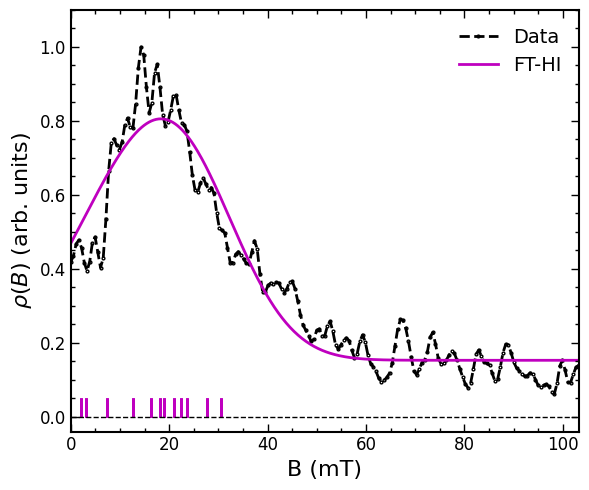

In [35]:
fig, ax = plt.subplots(
    1, 1, 
    figsize=(6, 5), 
    sharex=True, 
    # gridspec_kw={'height_ratios': [3, 1]}
)
#################################################################################
# Error bar styling
capsize = 3
capthick = 1
alpha = 1  # Transparency for plotting

# Data plot style
dfmt = '--o'          # Dashed line with circle markers
dlc = 'k'             # Data line color: black
dlw = 2               # Data line width
dms = 2               # Data marker size
dmew = 1.0            # Data marker edge width
delw = 1.5            # Error line width
dfills = 'none'       # Fill style: no fill
dlabel = 'Data'  # Data label (for legend)

# Fit plot style
flc = 'm'             # Fit line color: red
fls = '-'             # Fit line style: solid
flw = 2               # Fit line width
#################################################################################
ax.errorbar(
    XDATA*GAUSS_TO_MILLITESLA,
    YDATA,
    yerr=None,
    fmt=dfmt,
    lw=dlw,
    ms=dms,
    mew=dmew,
    mfc='white',
    mec=dlc,
    color=dlc,
    capsize=capsize,
    capthick=capthick,
    elinewidth=delw,
    fillstyle=dfills,
    label=dlabel,
    alpha=None,
    zorder=0     
)
#################################################################################
ax.plot(
    pristine_fitres['xfit']*GAUSS_TO_MILLITESLA,
    pristine_fitres['yfit'],
    color=flc,
    ls=fls,
    lw=flw,
    # label=flabel,
    label='FT-HI',
    alpha=None,
    zorder=1
)

dipolar=pristine_fitres['dipolar']*GAUSS_TO_MILLITESLA*pristine_fitres['parvalues'][1]
ax.vlines(
    dipolar, 
    ymin=-0.000, 
    ymax=+0.050, 
    color=flc,
    lw=flw,
    ls=fls
)

#################################################################################
fontsize=16
fancy_style_axes(ax)
ax.set_ylim([-0.04, 1.1])
ax.set_xlim([0, 14*MHZ_TO_GAUSS*0.1])

xlabel = 'Field (mT)'
xlabel = 'B (mT)'
ax.set_xlabel(xlabel, fontsize=fontsize)
ylabel=r'FFT (arb. units)'
ylabel=r'FT power (arb. units)'
ylabel=r'$\rho(B)$ (arb. units)'
ax.set_ylabel(ylabel, fontsize=fontsize)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Horizontal line at y=0
_ordered_legend(
    ax, 
    order_list=('Data', ), 
    ncol=1,
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=14,
    frameon=False,
    handlelength=2.0, 
    columnspacing=1.2,

)


#################################################################################
plt.tight_layout()
figname='SZRO_undistorted_muSRfit_distributions.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

equivalent positions with lattice distortions

In [36]:
# host_lattice = Structure.from_file(os.path.join(dpath, 'SZRO_monoP.cif'))
host_lattice = p_st.copy()

In [37]:
idx = 0

r_idx = [uniq['idx'] for uniq in unique_cluster]

# output
uniq = unique_cluster[idx]
rlx_st = Structure.from_dict(uniq['rlxd_struct'])

# input
file = f"{r_idx[idx]}.in"
file = os.path.join(folder, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_st = AseAtomsAdaptor.get_structure(inp_ase)

# # output
# file = f"{r_idx[idx]}.out"
# file = os.path.join(folder, file)
# rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
# rlx_st = AseAtomsAdaptor.get_structure(rlx_ase)

In [38]:
all_results = []
all_contribs = []

r_idx = [uniq['idx'] for uniq in unique_cluster]

for idx, uniq in enumerate(unique_cluster):
    # 1. Load relaxed output structure from dict
    rlx_st = Structure.from_dict(uniq['rlxd_struct'])

    # 2. Load pristine/input structure from Quantum ESPRESSO .in file
    filename = f"{r_idx[idx]}.in"
    filepath = os.path.join(folder, filename)
    inp_ase = read_from_file(filepath, format="espresso-in")
    inp_st = AseAtomsAdaptor.get_structure(inp_ase)

    distort_equiv_structs = get_structs(
        p_st=inp_st,
        rlx_st=rlx_st,
        host_st=host_lattice.copy(),
        min_distance=0.3
    )

    # print(idx, len(distort_equiv_structs))
    _contribs = []
    for site in distort_equiv_structs:
        if site.structure is not None:
            contribs = rfields(
                p_st=host_lattice,
                magmoms=magmoms,
                sc_mat=sc_matrix,
                r_supst=site.structure,
                cont_field=0,
                # muon_label: str = "H",
            )
            _contribs.append(contribs)
    
    all_contribs.extend(_contribs)

# print(len(all_contribs))  # Outputs: 48

relax_field_contribs = deepcopy(all_contribs)

In [39]:
relaxed_diplst_G = [field.total_norm[0] for field in relax_field_contribs]
relaxed_diplst_G = np.array(relaxed_diplst_G)
relaxed_diplst_G*= TESLA_TO_GAUSS

In [40]:
parinit   = [5.17, 0.06, 100.0, 0.15276920]
parmin    = [0.0,  0.00,   0.0, 0.0]
parmax    = [12.0, 1.00, 300.0, 1.0]
varyflags = [True, True, True, False]  # Fix background offset

# 1. Run the fit
relaxed_fitres = fit_gaussian_model(
        xdat=xdat,
        ydat=ydat,
        diplst=relaxed_diplst_G,
        parinit=parinit,
        parmin_bounds=parmin,
        parmax_bounds=parmax,
        vary_flags=varyflags
    )

relaxed_fitres['values_errors_pm'] = build_printable_parameters(relaxed_fitres, mode='pm')
relaxed_fitres['values_errors_cs'] = build_printable_parameters(relaxed_fitres, mode='compact')

print(f"Backend Used: {relaxed_fitres['backend']}")
print(f"R^2 Score:    {relaxed_fitres['r2squared']:.6f}")

for name, val, err in zip(
    relaxed_fitres['parnames'], relaxed_fitres['parvalues'], relaxed_fitres['parerrors']
    ):
    print(f"  {name:10s} = {val:.6f} +/- {err:.6f}")

# Extra functionality if lmfit ran:
if relaxed_fitres['backend'] == 'lmfit':
    print("\n--- Full LMfit Report ---")
    print(relaxed_fitres['raw_result'].fit_report())

Backend Used: lmfit
R^2 Score:    0.899414
  amplitude  = 9.688047 +/- 0.249827
  magmom     = 0.229372 +/- 0.004816
  sigma      = 109.070834 +/- 6.380282
  offset     = 0.152769 +/- 0.000000

--- Full LMfit Report ---
[[Model]]
    Model(sum_gaussians_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 62
    # data points      = 296
    # variables        = 3
    chi-square         = 1.81080448
    reduced chi-square = 0.00618022
    Akaike info crit   = -1502.59012
    Bayesian info crit = -1491.51904
    R-squared          = 0.89941435
[[Variables]]
    amplitude:  9.68804685 +/- 0.24982669 (2.58%) (init = 5.17)
    magmom:     0.22937210 +/- 0.00481581 (2.10%) (init = 0.06)
    sigma:      109.070834 +/- 6.38028162 (5.85%) (init = 100)
    offset:     0.1527692 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma)  = +0.7021
    C(magmom, sigma)     = -0.4814
    C(amplitude, magmom) = -0.2358


In [41]:
for line in relaxed_fitres['values_errors_cs']:
    print(line)

Amp: 9.7(2)
$\mu$/Re: 0.229(5) $\mu_B$
$\sigma$: 10.9(6) mT
Bkg: 0.1528 (fixed)
R$^2$ = 0.8994


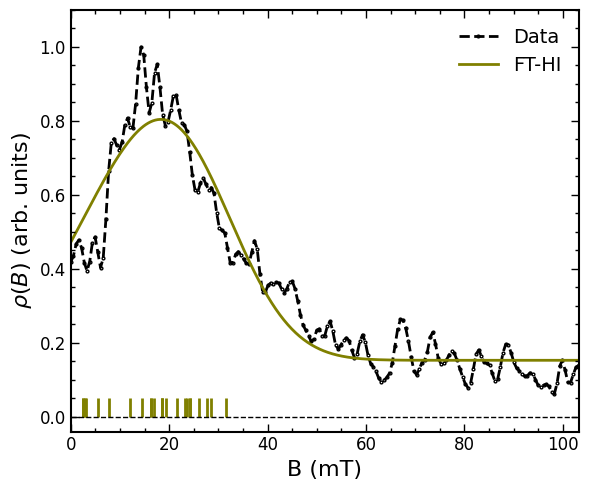

In [42]:
fig, ax = plt.subplots(
    1, 1, 
    figsize=(6, 5), 
    sharex=True, 
    # gridspec_kw={'height_ratios': [3, 1]}
)
#################################################################################
# Error bar styling
capsize = 3
capthick = 1
alpha = 1  # Transparency for plotting

# Data plot style
dfmt = '--o'          # Dashed line with circle markers
dlc = 'k'             # Data line color: black
dlw = 2               # Data line width
dms = 2               # Data marker size
dmew = 1.0            # Data marker edge width
delw = 1.5            # Error line width
dfills = 'none'       # Fill style: no fill
dlabel = 'Data'  # Data label (for legend)

# Fit plot style
flc = 'olive'             # Fit line color: red
fls = '-'             # Fit line style: solid
flw = 2               # Fit line width
#################################################################################
ax.errorbar(
    XDATA*GAUSS_TO_MILLITESLA,
    YDATA,
    yerr=None,
    fmt=dfmt,
    lw=dlw,
    ms=dms,
    mew=dmew,
    mfc='white',
    mec=dlc,
    color=dlc,
    capsize=capsize,
    capthick=capthick,
    elinewidth=delw,
    fillstyle=dfills,
    label=dlabel,
    alpha=None,
    zorder=0     
)
#################################################################################
ax.plot(
    relaxed_fitres['xfit']*GAUSS_TO_MILLITESLA,
    relaxed_fitres['yfit'],
    color=flc,
    ls=fls,
    lw=flw,
    # label=flabel,
    label='FT-HI',
    alpha=None,
    zorder=1
)

dipolar=relaxed_fitres['dipolar']*GAUSS_TO_MILLITESLA*relaxed_fitres['parvalues'][1]
ax.vlines(
    dipolar, 
    ymin=-0.000, 
    ymax=+0.050, 
    color=flc,
    lw=flw,
    ls=fls
)

#################################################################################
fontsize=16
fancy_style_axes(ax)
ax.set_ylim([-0.04, 1.1])
ax.set_xlim([0, 14*MHZ_TO_GAUSS*0.1])

xlabel = 'Field (mT)'
xlabel = 'B (mT)'
ax.set_xlabel(xlabel, fontsize=fontsize)
ylabel=r'FFT (arb. units)'
ylabel=r'FT power (arb. units)'
ylabel=r'$\rho(B)$ (arb. units)'
ax.set_ylabel(ylabel, fontsize=fontsize)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Horizontal line at y=0
_ordered_legend(
    ax, 
    order_list=('Data', ), 
    ncol=1,
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=14,
    frameon=False,
    handlelength=2.0, 
    columnspacing=1.2,

)


#################################################################################
plt.tight_layout()
figname='SZRO_distorted_muSRfit_distributions.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

both plots

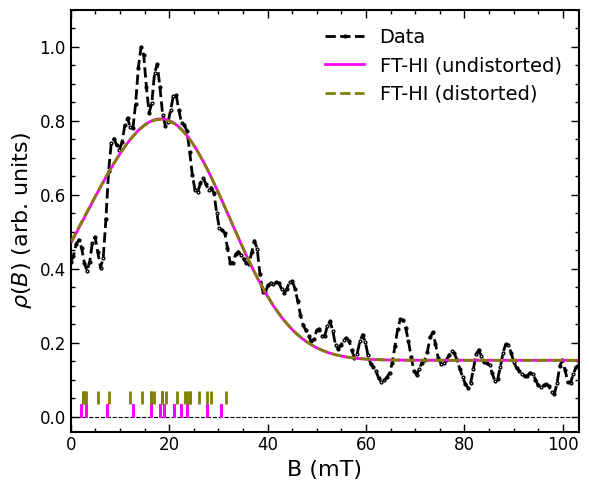

In [43]:
# 1. Figure setup
fig, ax = plt.subplots(figsize=(6, 5))

# 2. Plot Experimental Data
ax.errorbar(
    XDATA * GAUSS_TO_MILLITESLA, YDATA, yerr=None,
    fmt='--o', lw=2, ms=2, mew=1.0, mfc='white', mec='k', color='k',
    capsize=3, capthick=1, elinewidth=1.5, fillstyle='none',
    label='Data', zorder=1
)

# 3. Define fit configurations for loop execution
fits_config = [
    {
        'data': pristine_fitres,
        'label': 'FT-HI (undistorted)',
        'color': 'magenta',
        'linestyle': 'solid',
        'ymin': 0.00,
        'ymax': 0.035,
        'zorder': 2,
    },
    {
        'data': relaxed_fitres,
        'label': 'FT-HI (distorted)',
        'color': 'olive',
        'linestyle': '--',
        'ymin': 0.035,
        'ymax': 0.070,
        'zorder': 3,
    },
]

# 4. Loop to plot fits and tick marks (vlines) efficiently
for fit in fits_config:
    res = fit['data']
    scale = res.get('parvalues', [1, 1])[1]
    
    # Plot Fit Line
    ax.plot(
        res['xfit'] * GAUSS_TO_MILLITESLA,
        res['yfit'],
        color=fit['color'],
        ls=fit['linestyle'],
        lw=2.0,
        label=fit['label'],
        zorder=fit['zorder']
    )
    
    # Plot Dipolar Ticks in a single vectorized pass
    dipolar_fields = res['dipolar'] * GAUSS_TO_MILLITESLA * scale
    ax.vlines(
        dipolar_fields, 
        ymin=fit['ymin'], 
        ymax=fit['ymax'], 
        color=fit['color'], 
        lw=2, 
        # alpha=0.85,
        zorder=fit['zorder'] + 2
    )

# 5. Axes styling and layout
fontsize = 16
fancy_style_axes(ax)

ax.axhline(y=0, color='k', ls='--', lw=0.8, zorder=0)
# ax.set_ylim([-0.04, 1.08])
# ax.set_xlim([0, 105])
ax.set_ylim([-0.04, 1.1])
ax.set_xlim([0, 14*MHZ_TO_GAUSS*0.1])

ax.set_xlabel(r'B (mT)', fontsize=fontsize)
ax.set_ylabel(r'$\rho(B)$ (arb. units)', fontsize=fontsize)

_ordered_legend(
    ax, 
    order_list=('Data', 'FT-HI (undistorted)', 'FT-HI (distorted)'), 
    ncol=1, fontsize=14, frameon=False, handlelength=2.0, columnspacing=1.2
)

plt.tight_layout()
figname='SZRO_distorted_vs_undistorted_muSRfit_distributions.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

In [44]:
for fit in fits_config:
    print(f"\nMain fit parameter summary for: {fit['label']}")
    res = fit['data']
    for line in res['values_errors_cs']:
        print(line)


Main fit parameter summary for: FT-HI (undistorted)
Amp: 4.8(1)
$\mu$/Re: 0.223(5) $\mu_B$
$\sigma$: 10.8(6) mT
Bkg: 0.1528 (fixed)
R$^2$ = 0.8998

Main fit parameter summary for: FT-HI (distorted)
Amp: 9.7(2)
$\mu$/Re: 0.229(5) $\mu_B$
$\sigma$: 10.9(6) mT
Bkg: 0.1528 (fixed)
R$^2$ = 0.8994


In [45]:
all_fit_results = {
    'fit': {
        'distorted': relaxed_fitres,
        'undistorted': pristine_fitres
    },
    'data': {
        'xdata': XDATA, 
        'ydata': YDATA,
        'host_lattice': host_lattice
    },
}

file = 'SZRO_fitdistributions_results.pkl'
file = os.path.join(dpath, file)

with open(file, 'wb') as f:
    pickle.dump(all_fit_results, f)

print(f"Successfully saved fit results to {file}")

Successfully saved fit results to ./SZRO_fitdistributions_results.pkl


radial displacements of the Sr, Zn, Re and O atoms from their equilibrium positions as a
function of their distances f

NOTE: This is for more refine relaxations, thus the displacements are so small as the relaxations were done from initial structure close to the global minima

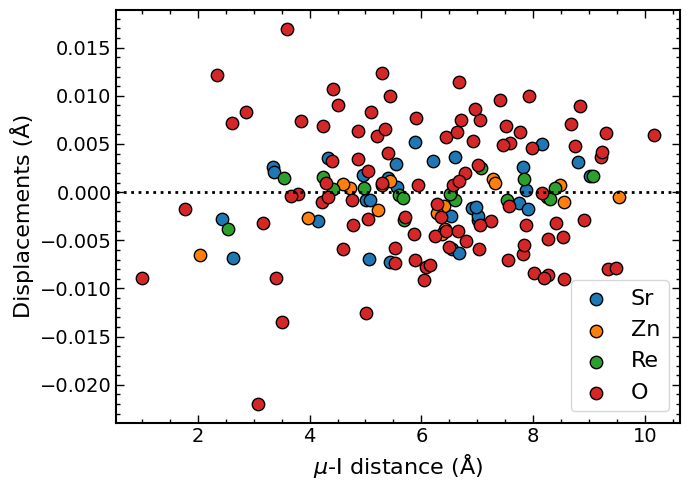

In [46]:
idx=1

filename = f"r{idx}.in"
filepath = os.path.join(folder, filename)
inp_ase = read_from_file(filepath, format="espresso-in")

filename = f"r{idx}.out"
filepath = os.path.join(folder, filename)
rlx_ase = read_from_file(filepath, format="espresso-out", index=-1)

radial_res = radial_to_dict(inp_ase.copy(), rlx_ase.copy(), muon_label='H')


fontsize=16
fig, ax = plt.subplots(figsize=(7, 5))

species = ('Sr', 'Zn', 'Re', 'O')
for i, specie in enumerate(species):
    sel = select_radial_displacement(
        radial_res,
        species=specie,
        distance_type='unperturbed',
        # cutoff=6.0,          # None -> no cutoff, keep everything
    )
    ax.scatter(
        sel['distance'], sel['displacements'], 
        # color='red', 
        s=80, 
        edgecolor='k', label=specie, zorder=1,
        )

ax.set_xlabel(r'$\mu$-I distance (Å)', fontsize=fontsize)
ax.set_ylabel(r'Displacements (Å)' , fontsize=fontsize)

# ax.set_xlim([-0.00, 10.0])
# ax.set_ylim([-0.08, 0.16])
ax.axhline(y=0.0, ls='dotted', lw=2, color='k')

ax.legend(frameon=False)
ax.legend(
    loc="lower right", fontsize=fontsize, ncol=1,
    frameon=True, handlelength=1.5, columnspacing=1.2,
)
fancy_style_axes(ax, fontsize=fontsize-2)


plt.tight_layout()
figname='radial_displacements.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()